In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import seaborn as sns
import math

from sklearn.base import BaseEstimator, TransformerMixin
import re


In [95]:
# 1. Load the data from the CSV file into a pandas DataFrame
# https://www.kaggle.com/c/titanic/data
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [96]:
print(df.isnull().sum())
print()
print(df['Survived'].value_counts())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survived
0    549
1    342
Name: count, dtype: int64


In [97]:
target = 'Survived'
features = [col for col in df.columns if col != target and col]

X_train = df[features]
y_train = df[target]

X_test = pd.read_csv('test.csv')
y_test_df = pd.read_csv('gender_submission.csv')
y_test = y_test_df['Survived']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.01, random_state=42)

In [98]:
# Exploratory Categorical
survival_rate_proportion_sex = df.groupby('Sex')['Survived'].mean()
survival_rate_proportion_pclass = df.groupby('Pclass')['Survived'].mean()
survival_rate_proportion_embarked = df.groupby('Embarked')['Survived'].mean()
missing_age_proportion = df["Age"].isnull().mean()
missing_cabin_proportion = df["Cabin"].isnull().mean()
missing_embarked_proportion = df["Embarked"].isnull().mean()

print(f'Missing Cabin {missing_cabin_proportion:,.4f}')
print(f'Missing Age {missing_age_proportion:,.4f}')
print(f'Missing Embarked {missing_embarked_proportion:,.4f}')

print(survival_rate_proportion_sex)
print(survival_rate_proportion_pclass)
print(survival_rate_proportion_embarked)

# Variablity - Not interpretable - Simple stats is interpratable such as simple linear regression - Want to know why people survive - 
# Correlation between survival and cabin - interaction affects and spurrous relationship affects - Ice cream greater chance of drowning
# Bootstrap - take sample and resample for estimate varaiacne in dataset 

# logistical variables looks at categorial variables
# multivariable lr models - adds up to a probaility
# Multicollinearity - multiibple variables say the same thing. Regression model - highly correlated with each other. Identy these before training
# Correlation matrix - between multipile variable at a time.

Missing Cabin 0.7710
Missing Age 0.1987
Missing Embarked 0.0022
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


AgeGroup
Child      0.579710
Adult      0.387597
Unknown    0.293785
Name: Survived, dtype: float64
FamilyGroup
Alone    0.303538
Small    0.578767
Large    0.161290
Name: Survived, dtype: float64


/var/folders/x0/dd1k8z7n1vv3hz8l45gqyk9w0000gn/T/ipykernel_80681/2081662599.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate_by_age = df.groupby('AgeGroup')['Survived'].mean()
/var/folders/x0/dd1k8z7n1vv3hz8l45gqyk9w0000gn/T/ipykernel_80681/2081662599.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate_by_family = df.groupby('FamilyGroup')['Survived'].mean()


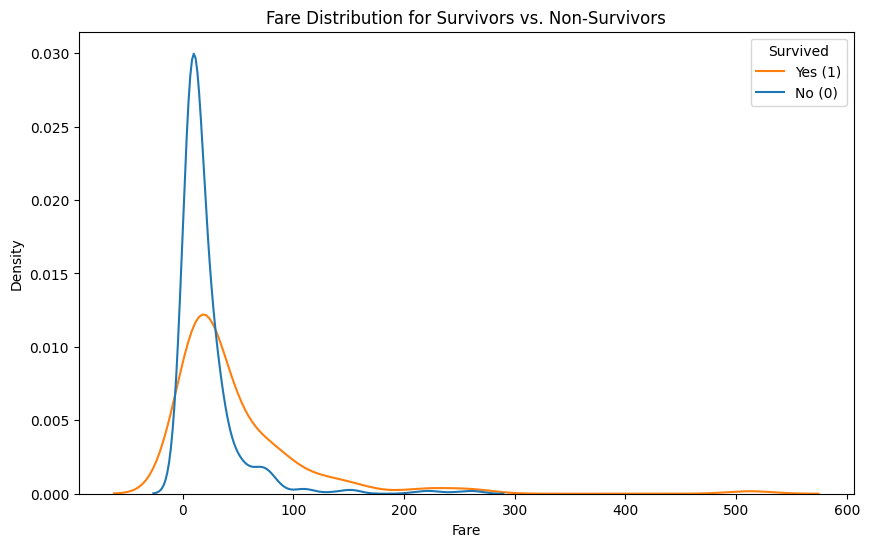

In [99]:
# Exploratory Numerical
bins = [0, 12, 100]
labels = ['Child', 'Adult']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)
df['AgeGroup'] = df['AgeGroup'].cat.add_categories('Unknown')
df['AgeGroup'] = df['AgeGroup'].fillna('Unknown')

survival_rate_by_age = df.groupby('AgeGroup')['Survived'].mean()
print(survival_rate_by_age)

labels = ['Alone', 'Small', 'Large']
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
bins = [0, 1, 4, df['FamilySize'].max()]
df['FamilyGroup'] = pd.cut(df['FamilySize'], bins=bins, labels=labels, right=True)

survival_rate_by_family = df.groupby('FamilyGroup')['Survived'].mean() 
print(survival_rate_by_family)


plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Fare', hue='Survived', common_norm=False)
plt.title('Fare Distribution for Survivors vs. Non-Survivors')
plt.xlabel('Fare')
plt.ylabel('Density')
plt.legend(title='Survived', labels=['Yes (1)', 'No (0)'])
plt.show()

In [100]:
def extract_cabin_letter(X):
    """
    Extracts the first letter from the 'Cabin' column (first column of X),
    fills missing values with 'U', and reshapes for the pipeline.
    """
    cabin_series = X.iloc[:, 0]
    letters = cabin_series.str[0].fillna('U') 
    
    return letters.values.reshape(-1, 1)
def create_age_groups(X):
    """
    Takes a 2D NumPy array of ages (which have already been imputed)
    and bins them into 'Child' and 'Adult'.
    """
    age_array = pd.Series(X.flatten()) 
    bins = [0, 12, 100]
    labels = ['Child', 'Adult']
    age_groups = pd.cut(age_array, bins=bins, labels=labels, right=True)
    
    return age_groups.astype(str).values.reshape(-1, 1)

def create_family_groups(X):
    """
    Takes a DataFrame/array with 'SibSp' and 'Parch' (in that order),
    calculates FamilySize, and bins it.
    """
    family_size = X.sum(axis=1) + 1
    bins = [0, 1, 4, np.inf]
    labels = ['Alone', 'Small', 'Large']
    groups = pd.cut(family_size, bins=bins, labels=labels, right=True)
    
    return groups.astype(str).values.reshape(-1, 1)

def check_has_cabin(X):
    """
    Takes the 'Cabin' column, checks for nulls,
    and returns 1 (HasCabin) or 0 (NoCabin).
    """
    cabin_series = pd.Series(X.iloc[:, 0]) 
    has_cabin = cabin_series.notnull().astype(int)
    return has_cabin.values.reshape(-1, 1)    


def check_is_alone(X):
    """
    Takes a DataFrame/array with 'SibSp' and 'Parch' (in that order),
    calculates FamilySize, and returns 1 if FamilySize==1, else 0.
    """
    family_size = X.sum(axis=1) + 1
    is_alone = (family_size == 1).astype(int)
    
    return is_alone.values.reshape(-1, 1)


class AgeImputerByGroup(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        # The columns are Pclass, Sex, Name, Age
        df = pd.DataFrame(X, columns=['Pclass', 'Sex', 'Name', 'Age'])
        
        # Extract titles
        df['Title'] = df['Name'].apply(TitleTransformer._extract_title)
        
        # Learn the medians
        self.medians_ = df.groupby(['Pclass', 'Sex', 'Title'])['Age'].median().to_dict()
        self.global_median_ = df['Age'].median()
        
        return self

    def transform(self, X, y=None):
        df = pd.DataFrame(X, columns=['Pclass', 'Sex', 'Name', 'Age']).copy()
        
        # Extract titles for the transform data
        df['Title'] = df['Name'].apply(TitleTransformer._extract_title)
        
        # Helper to apply imputation
        def impute_age(row):
            if pd.isnull(row['Age']):
                key = (row['Pclass'], row['Sex'], row['Title'])
                return self.medians_.get(key, self.global_median_)
            return row['Age']

        df['Age'] = df.apply(impute_age, axis=1)
        
        # Return only the imputed Age column as a numpy array
        return df[['Age']].values

class FareTicketTransformer(BaseEstimator, TransformerMixin):
    """
    Custom transformer that takes 'Ticket' and 'Fare' columns.
    
    It learns the frequency of each ticket from the training data.
    
    It outputs two new features:
    1. TicketFrequency: The count of that ticket in the training set.
    2. FarePerPerson: The 'Fare' divided by the 'TicketFrequency'.
    """
    def __init__(self):
        pass

    def fit(self, X, y=None):
        ticket_series = pd.Series(X.iloc[:, 0]) 
        self.ticket_counts_ = ticket_series.value_counts().to_dict()
        return self

    def transform(self, X, y=None):
        tickets = pd.Series(X.iloc[:, 0])
        fares = pd.Series(X.iloc[:, 1])
        
        ticket_freq = tickets.map(self.ticket_counts_).fillna(1)
        fare_per_person = fares / ticket_freq
        
        return np.stack([ticket_freq, fare_per_person], axis=1)
    

class TitleTransformer(BaseEstimator, TransformerMixin):
    """
    A custom transformer for the 'Name' column that:
    1. Extracts the title (e.g., 'Mr', 'Mrs').
    2. Groups rare titles (based on training set) into 'Other'.
    """
    def __init__(self, rare_threshold=10):
        self.rare_threshold = rare_threshold

    @staticmethod
    def _extract_title(name):
        m = re.search(r',\s*([^\.]+)\.', name)
        if m:
            return m.group(1).strip()
        return 'Unknown'

    def fit(self, X, y=None):
        name_series = pd.Series(X.iloc[:, 0])
        titles = name_series.apply(self._extract_title)
        
        title_counts = titles.value_counts()
        self.common_titles_ = title_counts[title_counts >= self.rare_threshold].index.tolist()
        
        return self

    def transform(self, X, y=None):
        name_series = pd.Series(X.iloc[:, 0])
        titles = name_series.apply(self._extract_title)
        titles_mapped = titles.apply(lambda x: x if x in self.common_titles_ else 'Other')

        return titles_mapped.values.reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        return ['Title']

In [101]:
print(df.isnull().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
AgeGroup         0
FamilySize       0
FamilyGroup      0
dtype: int64


In [102]:
numeric_features = [] 
categorical_features = ['Sex', 'Embarked']
ordinal_features = ['Pclass']
cabin_features = ['Cabin']
family_features = ['SibSp', 'Parch']
fare_ticket_features = ['Ticket', 'Fare']
age_features = ['Age']
name_features = ['Name']
age_impute_features = ['Pclass', 'Sex', 'Name', 'Age']

fare_ticket_transformer = Pipeline(steps=[
    ('fare_ticket', FareTicketTransformer()),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

age_impute_transformer = Pipeline(steps=[
    ('imputer', AgeImputerByGroup()),
])

age_group_transformer = Pipeline(steps=[
    ('create_age_groups', FunctionTransformer(create_age_groups)),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

title_transformer = Pipeline(steps=[
    ('extract_title', TitleTransformer(rare_threshold=10)),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

family_transformer = Pipeline(steps=[
    ('create_groups', FunctionTransformer(create_family_groups)),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

is_alone_transformer = Pipeline(steps=[
    ('check_alone', FunctionTransformer(check_is_alone))
])

has_cabin_transformer = Pipeline(steps=[
    ('check_cabin', FunctionTransformer(check_has_cabin))
]) 

cabin_transformer = Pipeline(steps=[
    ('get_letter', FunctionTransformer(extract_cabin_letter)),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('encoder', OrdinalEncoder(categories=[[1, 2, 3]])) 
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('title', title_transformer, name_features),
        ('cabin', cabin_transformer, cabin_features),
        ('family_group', family_transformer, family_features),
        ('is_alone', is_alone_transformer, family_features),
        ('fare_and_ticket', fare_ticket_transformer, fare_ticket_features),
        ('age_impute', age_impute_transformer, age_impute_features),
    ],
    remainder='drop'
)

# Create a second preprocessor to handle the imputed age
preprocessor2 = ColumnTransformer(
    transformers=[
        ('age_group', age_group_transformer, [8])
    ],
    remainder='passthrough'
)


pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('preprocessor2', preprocessor2),
    ('classifier', LogisticRegression(n_jobs=-1, random_state=42))
])

lr_param_grid = {
    'classifier__penalty': ['l1', 'l2'],
    'classifier__C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
    'classifier__solver': ['liblinear']
}

grid_search_lr = GridSearchCV(
    estimator=pipe_lr, 
    param_grid=lr_param_grid, 
    cv=5,
    scoring='accuracy'
)

models = {
    "Logistic Regression - Grid": grid_search_lr,
}

cv_results = []
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

for name, model in models.items():
    print(f"Running Cross-Validation for: {name}...")
    # Use cross_validate to get multiple scores at once
    scores = cross_validate(model, X_train, y_train, cv=5, scoring=scoring_metrics)
    
    cv_results.append({
        "Model": name,
        "Avg. Accuracy": f"{scores['test_accuracy'].mean():.4f}",
    })

# Print the results in a table format
print("\nTable 3: Cross-Validated Model Performance Comparison")
results_df = pd.DataFrame(cv_results).set_index('Model')
print(results_df)

Running Cross-Validation for: Logistic Regression - Grid...


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to


Table 3: Cross-Validated Model Performance Comparison
                           Avg. Accuracy
Model                                   
Logistic Regression - Grid        0.7395


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to

/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(


Logistic Regression - Grid...


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to

Model Accuracy on Test Set: 0.9282


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(


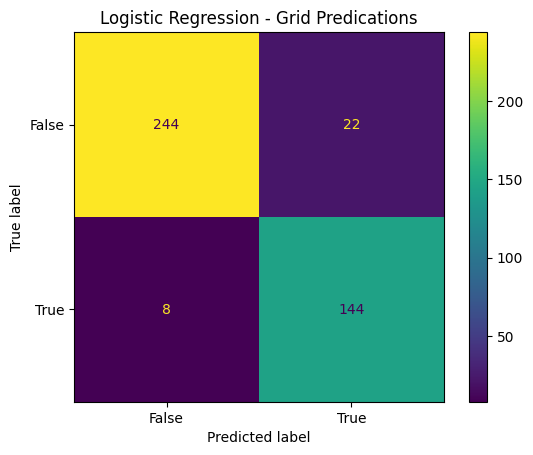

In [103]:
for name, model in models.items():
    print(f"{name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model Accuracy on Test Set: {accuracy:.4f}")
    class_names = y_test.astype(bool).unique().tolist()
    cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_names) 
    cm.ax_.set_title(f"{name} Predications")
    cm


In [104]:
new_passengers = pd.DataFrame({
    'Name': [
        'Sample, Mrs. Jane (Jane Doe)',  # For the 35-year-old female
        'Sample, Master. John (John Doe)', # For the 12-year-old male
        'Sample, Miss. Mary (Mary Doe)'  # For the 5-year-old female
    ],
    'Pclass': [1, 3, 2],
    'Sex': ['female', 'male', 'female'],
    'Age': [35, 12, 5],
    'Fare': [80.0, 71.25, 26.0],
    'Embarked': ['S', 'S', 'C'],
    'SibSp': [1, 1, 1],
    'Parch': [0, 0, 2],
    'Ticket': ['PC 17595', 'A/5 21171', '230136'],
    'Cabin': ['E34', np.nan, np.nan]
})

predictions = grid_search_lr.best_estimator_.predict(new_passengers)
prediction_text = ['Survived' if p == 1 else 'Did not Survive' for p in predictions]

print("\n--- Example Predictions ---")
for i, (index, passenger) in enumerate(new_passengers.iterrows()):
    print(f"Prediction for passenger {i+1} ({passenger['Sex']}, age {passenger['Age']}, class {passenger['Pclass']}): {prediction_text[i]}")
print("-" * 30)



--- Example Predictions ---
Prediction for passenger 1 (female, age 35, class 1): Survived
Prediction for passenger 2 (male, age 12, class 3): Survived
Prediction for passenger 3 (female, age 5, class 2): Survived
------------------------------


In [105]:
import pickle

with open('best_model - titanic.pkl', 'wb') as f:
    pickle.dump(grid_search_lr, f)

In [ ]:
predictions = grid_search_lr.best_estimator_.predict(X_test)

df_submission = pd.DataFrame({
    'PassengerId': X_test['PassengerId'],
    'Survived': predictions
})

df_submission.to_csv("submission - lr.csv", index=False, header=True)
grid_search_lr.best_estimator_.score(X_test, y_test)

0.9282296650717703